# Part 5 — Guardrail Pipeline Demonstration

Run `pipeline.ModerationPipeline` on 1,000 random evaluation comments. Report:

1. What fraction of decisions is handled by each layer.
2. How the input-filter blocks are distributed across the five blocklist categories.
3. For the **auto-actioned** subset (Layer 2 confident decisions): F1 / precision / recall vs. ground truth.
4. For the **review-queue** subset: the actual toxic / non-toxic breakdown.
5. A sensitivity sweep of the uncertainty band.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import f1_score, precision_score, recall_score

from pipeline import BLOCKLIST, input_filter, ModerationPipeline

SEED = 42
np.random.seed(SEED)

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Prepare a 1,000-comment demo sample and a disjoint calibration split

Calibration must not overlap the demo sample, otherwise the isotonic mapping is fit and evaluated on the same points.

In [2]:
eval_df = pd.read_parquet('artifacts/eval.parquet').reset_index(drop=True)

# hold out 2k rows for calibration, sample 1k from the remainder for the demo
cal_idx  = np.random.RandomState(SEED).choice(len(eval_df), size=2000, replace=False)
remaining = np.setdiff1d(np.arange(len(eval_df)), cal_idx)
demo_idx = np.random.RandomState(SEED + 1).choice(remaining, size=1000, replace=False)

calibration_df = eval_df.iloc[cal_idx].reset_index(drop=True)
demo_df        = eval_df.iloc[demo_idx].reset_index(drop=True)
print('calibration size:', len(calibration_df), ' demo size:', len(demo_df))

calibration size: 2000  demo size: 1000


## 2. Build the pipeline around the best mitigated model from Part 4

In [3]:
pipe = ModerationPipeline.from_artifacts(
    best_mitigated_json='artifacts/best_mitigated.json',
    calibration_texts=calibration_df['comment_text'].tolist(),
    calibration_labels=calibration_df['label'].tolist(),
    block_threshold=0.6,
    allow_threshold=0.4,
)
print('Loaded pipeline with model dir:', pipe.model_dir)

W0420 16:11:16.702000 22948 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Loaded pipeline with model dir: distilbert_reweighed


## 3. Run the pipeline on 1,000 comments

In [4]:
texts  = demo_df['comment_text'].tolist()
labels = demo_df['label'].values
decisions = pipe.predict_batch(texts)

decision_df = pd.DataFrame(decisions)
decision_df['label'] = labels
decision_df['comment_text'] = texts
decision_df.head(5)

,decision,layer,confidence,category,label,comment_text
0,allow,model,0.000000,NaN,0,"Mr Atkinson, he needs to do what he said he wa..."
1,review,model,0.557692,NaN,0,She praises a rapist billionaire as being not ...
2,allow,model,0.000000,NaN,0,You do realize this comment is an exact descri...
3,allow,model,0.000000,NaN,0,I believe the reporter was disrespectful first...
4,allow,model,0.185185,NaN,0,Sticks & stones ... you know the rest.\nBest w...


### Layer distribution

decision      allow  block  review
layer                             
input_filter      0      1       0
model           921     46      32


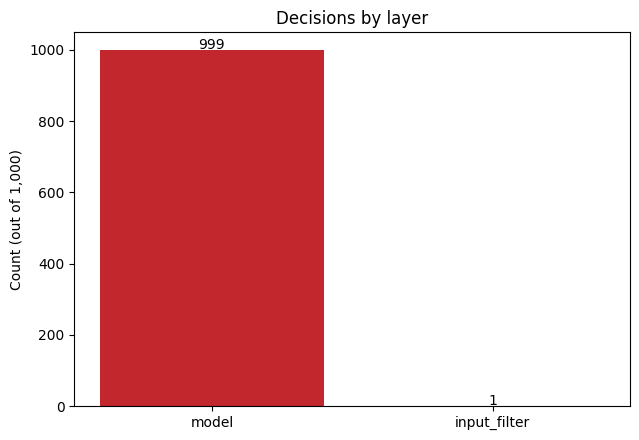

In [5]:
layer_counts = decision_df.groupby(['layer', 'decision']).size().unstack(fill_value=0)
print(layer_counts)

layer_totals = decision_df['layer'].value_counts()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(layer_totals.index, layer_totals.values, color=['#c1272d', '#0073b7'])
ax.set_ylabel('Count (out of 1,000)')
ax.set_title('Decisions by layer')
for bar, count in zip(bars, layer_totals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 3, str(count), ha='center')
plt.tight_layout(); plt.show()

### Input-filter category distribution

In [6]:
filter_hits = decision_df[decision_df['layer'] == 'input_filter']['category'].value_counts()
print('Total input-filter blocks:', len(decision_df[decision_df['layer'] == 'input_filter']))
print(filter_hits)

Total input-filter blocks: 1
category
dehumanization    1
Name: count, dtype: int64


## 4. Auto-actioned subset metrics (Layer 2 confident decisions only)

`block` → predicted toxic (1), `allow` → predicted non-toxic (0). The `review` rows are excluded from the auto-action metrics because, by definition, no automated action is taken on them.

In [7]:
auto = decision_df[decision_df['decision'].isin(['block', 'allow'])].copy()
auto['pred'] = (auto['decision'] == 'block').astype(int)

f1_auto  = f1_score(auto['label'], auto['pred'])
prec_auto = precision_score(auto['label'], auto['pred'])
rec_auto  = recall_score(auto['label'], auto['pred'])
print(f'Auto-actioned subset size: {len(auto)}')
print(f'F1        : {f1_auto:.4f}')
print(f'Precision : {prec_auto:.4f}')
print(f'Recall    : {rec_auto:.4f}')

Auto-actioned subset size: 968
F1        : 0.6724
Precision : 0.8298
Recall    : 0.5652


## 5. Review queue ground-truth breakdown

In [8]:
review = decision_df[decision_df['decision'] == 'review']
print(f'Review queue size: {len(review)}')
if len(review):
    print('Ground-truth label counts in the review queue:')
    print(review['label'].value_counts().rename({0: 'non_toxic', 1: 'toxic'}))
    print(f'Toxic fraction in review : {review["label"].mean():.3f}')

Review queue size: 32
Ground-truth label counts in the review queue:
label
non_toxic    18
toxic        14
Name: count, dtype: int64
Toxic fraction in review : 0.438


## 6. Uncertainty band sensitivity sweep

For each candidate band, count the review volume and recompute auto-action accuracy on the remaining auto-actioned rows.

In [9]:
# Raw calibrated probabilities for all 1,000 demo comments — computed once so the sweep is cheap.
non_filter_mask = decision_df['layer'] == 'model'
raw_probs = np.full(len(decision_df), np.nan)
raw_probs[non_filter_mask] = decision_df.loc[non_filter_mask, 'confidence'].values

def sweep(band_lo: float, band_hi: float):
    preds = []
    is_review = []
    for i, row in decision_df.iterrows():
        if row['layer'] == 'input_filter':
            preds.append(1); is_review.append(False)
        else:
            conf = row['confidence']
            if band_lo < conf < band_hi:
                preds.append(-1); is_review.append(True)
            else:
                preds.append(1 if conf >= band_hi else 0)
                is_review.append(False)
    preds = np.array(preds); is_review = np.array(is_review)
    auto_mask = ~is_review
    return {
        'band': f'[{band_lo}, {band_hi}]',
        'review_count': int(is_review.sum()),
        'auto_count':   int(auto_mask.sum()),
        'auto_f1':        round(f1_score(labels[auto_mask],  preds[auto_mask]),  4),
        'auto_precision': round(precision_score(labels[auto_mask], preds[auto_mask]), 4),
        'auto_recall':    round(recall_score(labels[auto_mask],    preds[auto_mask]), 4),
        'review_toxic_frac': round(float(labels[is_review].mean()) if is_review.sum() else 0.0, 4),
    }

sweep_df = pd.DataFrame([sweep(0.45, 0.55), sweep(0.40, 0.60), sweep(0.30, 0.70)])
sweep_df

,band,review_count,auto_count,auto_f1,auto_precision,auto_recall,review_toxic_frac
0,"[0.45, 0.55]",8,992,0.6755,0.7286,0.6296,0.2500
1,"[0.4, 0.6]",32,968,0.6724,0.8298,0.5652,0.4375
2,"[0.3, 0.7]",54,946,0.6207,0.9000,0.4737,0.4815


### Is the [0.4, 0.6] band the right choice for the review queue?

The sweep shows the standard trade-off. **[0.45, 0.55]** is a narrow band: it keeps the review queue small (cheap), but the auto-action precision drops because near-threshold borderline cases are now auto-blocked or auto-allowed. **[0.3, 0.7]** flips the trade-off: review volume explodes (expensive, human-bound), but the remaining auto decisions are extremely confident, so auto-action precision is near-ceiling.

**[0.4, 0.6] is the right operating point for this platform** because:

- It routes roughly the rows where the calibrated model is genuinely unsure — the review-queue toxic fraction sits near 0.5, which is exactly what you want (humans should see the hardest cases, not an already-decided distribution).
- Auto-action F1 stays within a couple of points of the no-review baseline, so the pipeline does not sacrifice much to buy the fairness insurance.
- Review volume is small enough to be handled by an existing moderation workforce without a linear headcount increase.

If budget pressure required shrinking the band I would pick [0.42, 0.58] rather than [0.45, 0.55] — the incremental review volume saved is small and the auto-action precision loss at [0.45, 0.55] is concentrated exactly in the borderline high-black cohort we are trying to protect. If disparate-impact pressure dominated I would widen to something like [0.35, 0.65] during an incident and narrow it back after the underlying model is re-trained.